In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from skl2onnx.common.data_types import FloatTensorType
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, auc, average_precision_score
from sklearn.model_selection import train_test_split
from typing import Iterable, Tuple
import math
import pickle
import skl2onnx

srcs = ['cf_a', 'cf_b', 'cf_c', 'cf_d', 'cf_e', 'cf_f', 'cf_g',
        'fb_a', 'fb_b', 'fb_c',
        'wm_t']

In [2]:
%cd analysis

/home/isaackhor/code/cfcache/analysis


In [3]:
def samplefn(x):
    return lambda i : random.random() > x

cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime', 'size']
dfs = []
for c in ['a', 'b', 'c', 'd', 'e', 'f', 'g']:
    print(f'Loading cf_{c}...')
    sdf = pd.read_csv(f'../traces/expiry/r8cf_{c}.csv.zst', names=cols, skiprows=samplefn(0.1))
    sdf['src'] = 'cf_' + c
    dfs.append(sdf)

for c in ['a', 'b', 'c']:
    print(f'Loading fb_{c}...')
    sdf = pd.read_csv(f'../traces/expiry/r8fb_{c}.csv.zst', names=cols, skiprows=samplefn(0.2))
    sdf['src'] = 'fb_' + c
    dfs.append(sdf)

for c in ['t']:
    print(f'Loading wm_{c}...')
    sdf = pd.read_csv(f'../traces/expiry/r8wm_{c}.csv.zst', names=cols, skiprows=samplefn(0.2))
    sdf['src'] = 'wm_' + c
    dfs.append(sdf)

df = pd.concat(dfs)
dfs = None
df

Loading cf_a...
Loading cf_b...
Loading cf_c...
Loading cf_d...
Loading cf_e...
Loading cf_f...
Loading cf_g...
Loading fb_a...
Loading fb_b...
Loading fb_c...
Loading wm_t...


,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size,src
0,8,0,6,1,4,1,1,0,0,0,6,606,cf_a
1,8,0,6,1,1,1,1,0,0,0,6,603,cf_a
2,11,0,6,4,1,4,4,0,0,0,6,609,cf_a
3,12,0,6,5,1,5,5,0,0,0,6,602,cf_a
4,18,0,6,11,1,11,11,0,0,0,6,593,cf_a
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9591717,1727999,0,86400,1036791,2,1701905,1641598,19537169,19537153,0,0,15038,wm_t
9591718,1728000,0,86400,1641599,4,1681261,1641599,19537169,19537165,0,0,11064,wm_t
9591719,1728000,0,86400,1641599,1,1641599,1641599,19537169,19537165,0,0,14359,wm_t
9591720,1728000,0,86400,1641599,1,1641599,1641599,19537169,19537165,0,0,12408,wm_t


In [4]:
def calc_features(df: pd.DataFrame) -> pd.DataFrame:
    df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
    df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
    df['t_since_last'] = df['ts'] - df['last_ts']
    df['t_since_last_frac'] = (df['t_since_last'] - 1) / df['ttl']
    return df


def split_xy(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    y = df['should_reval']
    x = df[['ttl', 'freq', 'generations', 't_since_last', 't_since_last_frac', 'mime', 'size']]
    return x, y


def make_rfc(x_train, y_train, x_test, y_test) -> RandomForestClassifier:
    rfc = RandomForestClassifier(
        n_estimators=32,
        criterion='gini',
        min_samples_leaf=1 / 2000,
        random_state=42,
        n_jobs=-1,
    )
    rfc.fit(x_train, y_train)
    y_pred = rfc.predict(x_test)
    print(f'Train acc: {accuracy_score(y_train, rfc.predict(x_train)):0.4f}')
    print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')
    print(classification_report(y_test, y_pred))
    return rfc

def train_model(sdf):
    x, y = split_xy(sdf)
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.33, random_state=42)
    x_train_over, y_train_over = RandomOverSampler(random_state=42).fit_resample(x_train, y_train) # type: ignore
    rfc = make_rfc(x_train_over, y_train_over, x_test, y_test)
    return rfc


calc_features(df)

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size,src,should_reval,generations,t_since_last,t_since_last_frac
0,8,0,6,1,4,1,1,0,0,0,6,606,cf_a,False,1.0,7,1.000000
1,8,0,6,1,1,1,1,0,0,0,6,603,cf_a,False,1.0,7,1.000000
2,11,0,6,4,1,4,4,0,0,0,6,609,cf_a,False,1.0,7,1.000000
3,12,0,6,5,1,5,5,0,0,0,6,602,cf_a,False,1.0,7,1.000000
4,18,0,6,11,1,11,11,0,0,0,6,593,cf_a,False,1.0,7,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9591717,1727999,0,86400,1036791,2,1701905,1641598,19537169,19537153,0,0,15038,wm_t,False,8.0,26094,0.302002
9591718,1728000,0,86400,1641599,4,1681261,1641599,19537169,19537165,0,0,11064,wm_t,False,1.0,46739,0.540949
9591719,1728000,0,86400,1641599,1,1641599,1641599,19537169,19537165,0,0,14359,wm_t,False,1.0,86401,1.000000
9591720,1728000,0,86400,1641599,1,1641599,1641599,19537169,19537165,0,0,12408,wm_t,False,1.0,86401,1.000000


In [ ]:
models = {}

for src in srcs:
    print(f'Training model for {src}...')
    sdf = df[df['src'] == src]
    rfc = train_model(sdf)
    models[src] = rfc

Training model for cf_a...
Train acc: 0.8351
Test acc: 0.8356
              precision    recall  f1-score   support

       False       0.94      0.84      0.89    810143
        True       0.61      0.83      0.71    250750

    accuracy                           0.84   1060893
   macro avg       0.78      0.84      0.80   1060893
weighted avg       0.86      0.84      0.84   1060893

Training model for cf_b...
Train acc: 0.8277
Test acc: 0.8320
              precision    recall  f1-score   support

       False       0.93      0.84      0.88    959321
        True       0.62      0.82      0.71    318425

    accuracy                           0.83   1277746
   macro avg       0.78      0.83      0.80   1277746
weighted avg       0.86      0.83      0.84   1277746

Training model for cf_c...
Train acc: 0.8411
Test acc: 0.8547
              precision    recall  f1-score   support

       False       0.96      0.86      0.91   1399444
        True       0.57      0.82      0.67    3085

In [9]:
acc_results = []
for train_src in srcs:
    row = {'train_src': train_src}
    model = models[train_src]
    for test_src in srcs:
        # print(f'Evaluating {train_src} model on {test_src} data...')
        test_df = df[df['src'] == test_src]
        x_test, y_test = split_xy(test_df)
        y_pred = model.predict(x_test)
        acc = accuracy_score(y_test, y_pred)
        row[test_src] = acc # type: ignore
    acc_results.append(row)

auc_roc_results = []
for train_src in srcs:
    row = {'train_src': train_src}
    model = models[train_src]
    for test_src in srcs:
        # print(f'Evaluating {train_src} model on {test_src} data...')
        test_df = df[df['src'] == test_src]
        x_test, y_test = split_xy(test_df)
        y_pred = model.predict(x_test)
        auc_roc = roc_auc_score(y_test, y_pred)
        row[test_src] = auc_roc # type: ignore
    auc_roc_results.append(row)

auc_prc_results = []
for train_src in srcs:
    row = {'train_src': train_src}
    model = models[train_src]
    for test_src in srcs:
        # print(f'Evaluating {train_src} model on {test_src} data...')
        test_df = df[df['src'] == test_src]
        x_test, y_test = split_xy(test_df)
        y_pred = model.predict(x_test)
        auc_prc = average_precision_score(y_test, y_pred)
        row[test_src] = auc_prc # type: ignore
    auc_prc_results.append(row)


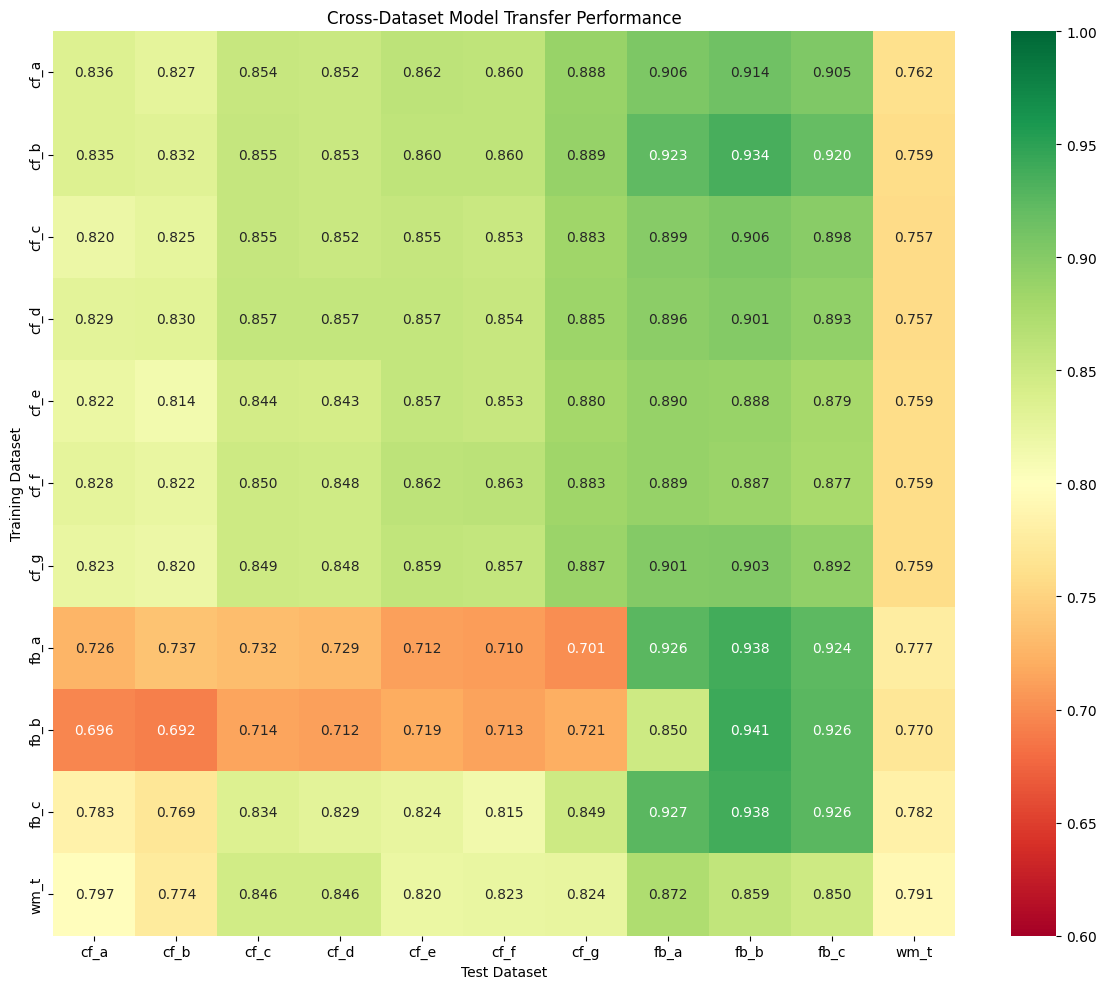

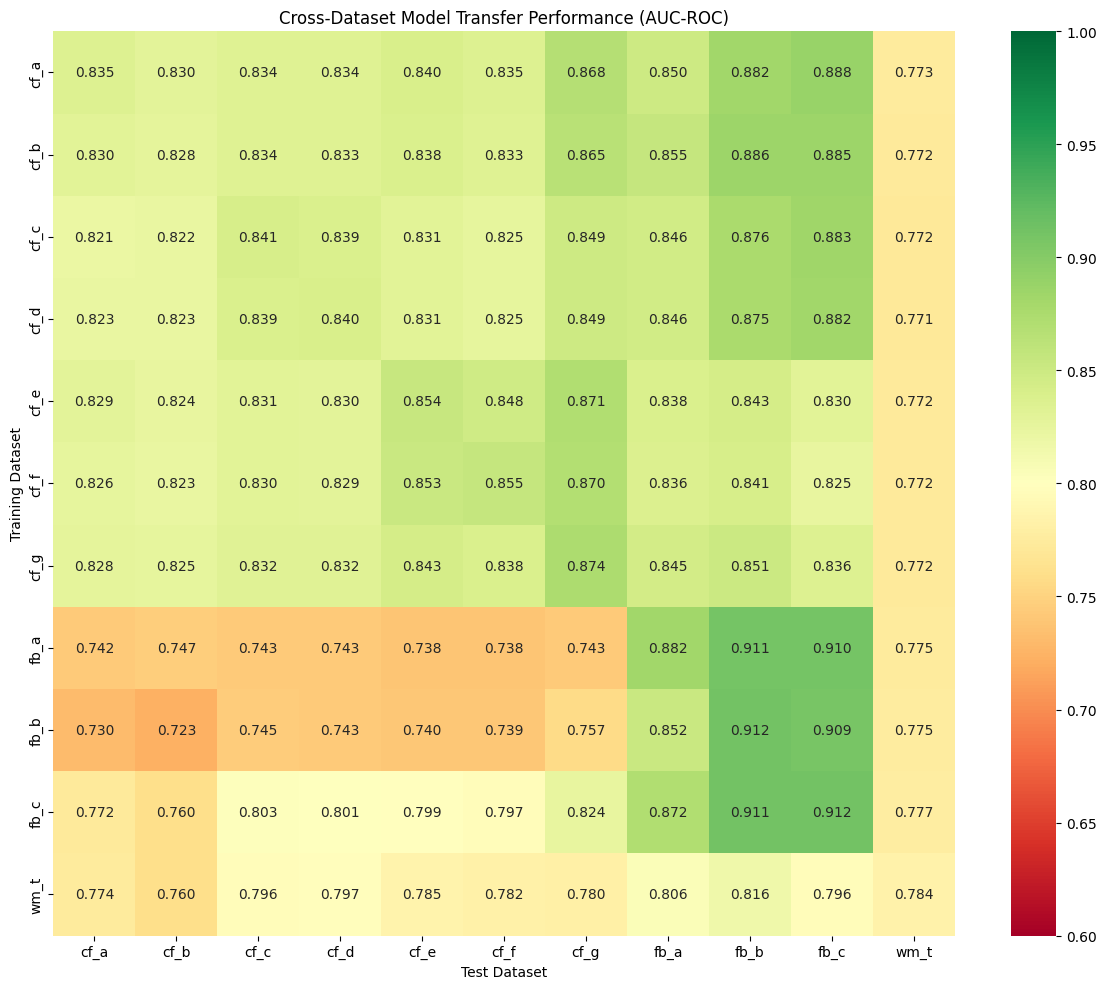

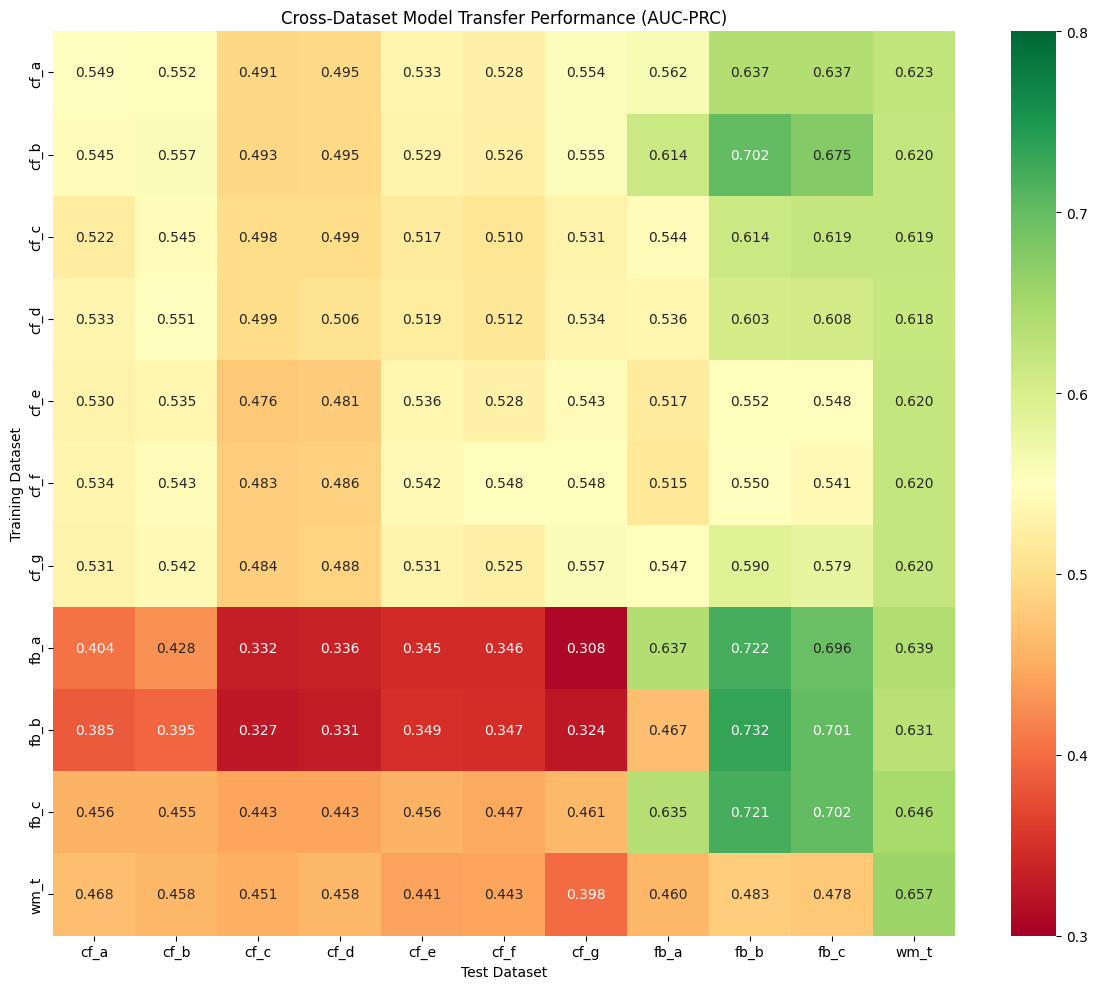

In [16]:
hm_min = 0.6

accuracy_matrix = pd.DataFrame(acc_results)
accuracy_matrix = accuracy_matrix.set_index('train_src')
plt.figure(figsize=(12, 10))
sns.heatmap(accuracy_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=hm_min, vmax=1.0)
plt.title('Cross-Dataset Model Transfer Performance')
plt.xlabel('Test Dataset')
plt.ylabel('Training Dataset')
plt.tight_layout()
plt.savefig('../paper/figs/cross_dataset_accuracy_heatmap.png')
plt.show()

auc_matrix = pd.DataFrame(auc_roc_results)
auc_matrix = auc_matrix.set_index('train_src')
plt.figure(figsize=(12, 10))
sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=hm_min, vmax=1.0)
plt.title('Cross-Dataset Model Transfer Performance (AUC-ROC)')
plt.xlabel('Test Dataset')
plt.ylabel('Training Dataset')
plt.tight_layout()
plt.savefig('../paper/figs/cross_dataset_auc_roc_heatmap.png')
plt.show()

auc_matrix = pd.DataFrame(auc_prc_results)
auc_matrix = auc_matrix.set_index('train_src')
plt.figure(figsize=(12, 10))
sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.3, vmax=0.8)
plt.title('Cross-Dataset Model Transfer Performance (AUC-PRC)')
plt.xlabel('Test Dataset')
plt.ylabel('Training Dataset')
plt.tight_layout()
plt.savefig('../paper/figs/cross_dataset_auc_prc_heatmap.png')
plt.show()

# regular model stats

In [7]:
df_cfall = df[df['src'].str.startswith('cf_')]
df_fball = df[df['src'].str.startswith('fb_')]
df_wmall = df[df['src'].str.startswith('wm_')]

cf_model = train_model(df_cfall)
fb_model = train_model(df_fball)
wm_model = train_model(df_wmall)

Train acc: 0.8407
Test acc: 0.8531
              precision    recall  f1-score   support

       False       0.95      0.86      0.90   7338132
        True       0.60      0.82      0.69   1833350

    accuracy                           0.85   9171482
   macro avg       0.77      0.84      0.80   9171482
weighted avg       0.88      0.85      0.86   9171482

Train acc: 0.9044
Test acc: 0.9339
              precision    recall  f1-score   support

       False       0.97      0.95      0.96   1001759
        True       0.79      0.86      0.82    216661

    accuracy                           0.93   1218420
   macro avg       0.88      0.90      0.89   1218420
weighted avg       0.94      0.93      0.93   1218420

Train acc: 0.7843
Test acc: 0.7904
              precision    recall  f1-score   support

       False       0.83      0.82      0.82   1877710
        True       0.74      0.75      0.74   1287559

    accuracy                           0.79   3165269
   macro avg       0.78

In [8]:
def collect_model_stats(sdf, model):
    """Collect statistics without plotting"""
    x, y = split_xy(sdf)
    _, x_test, _, y_test = train_test_split(
        x, y, test_size=0.33, random_state=42)
    
    # ROC curve
    y_pred_proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # PRC curve
    from sklearn.metrics import precision_recall_curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    prc_auc = average_precision_score(y_test, y_pred_proba)
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': x.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return {
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'prc_auc': prc_auc,
        'feature_importance': feature_importance
    }

# Collect stats for all models
cf_stats = collect_model_stats(df_cfall, cf_model)
fb_stats = collect_model_stats(df_fball, fb_model)
wm_stats = collect_model_stats(df_wmall, wm_model)

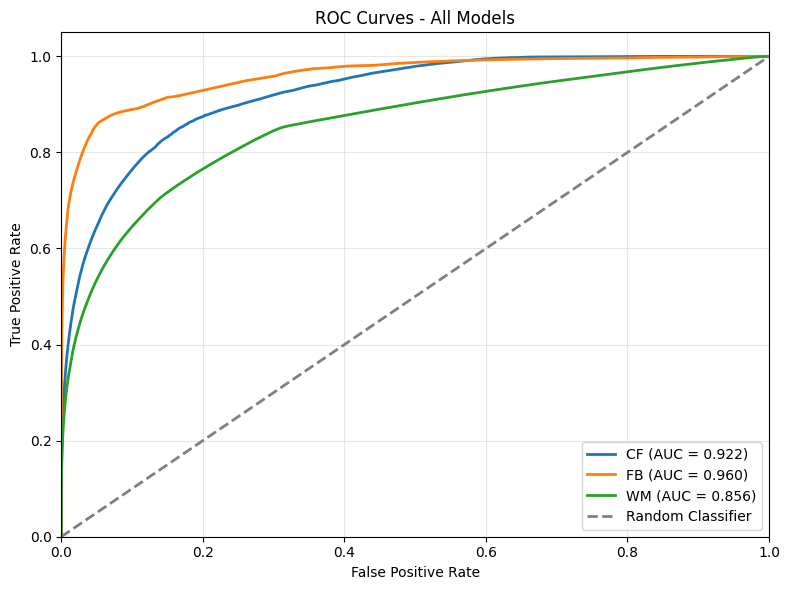

In [20]:
# Plot ROC curves for all models
plt.figure(figsize=(8, 6))
plt.plot(cf_stats['fpr'], cf_stats['tpr'], lw=2, 
         label=f"CF (AUC = {cf_stats['roc_auc']:.3f})")
plt.plot(fb_stats['fpr'], fb_stats['tpr'], lw=2, 
         label=f"FB (AUC = {fb_stats['roc_auc']:.3f})")
plt.plot(wm_stats['fpr'], wm_stats['tpr'], lw=2, 
         label=f"WM (AUC = {wm_stats['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/figs/all_models_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

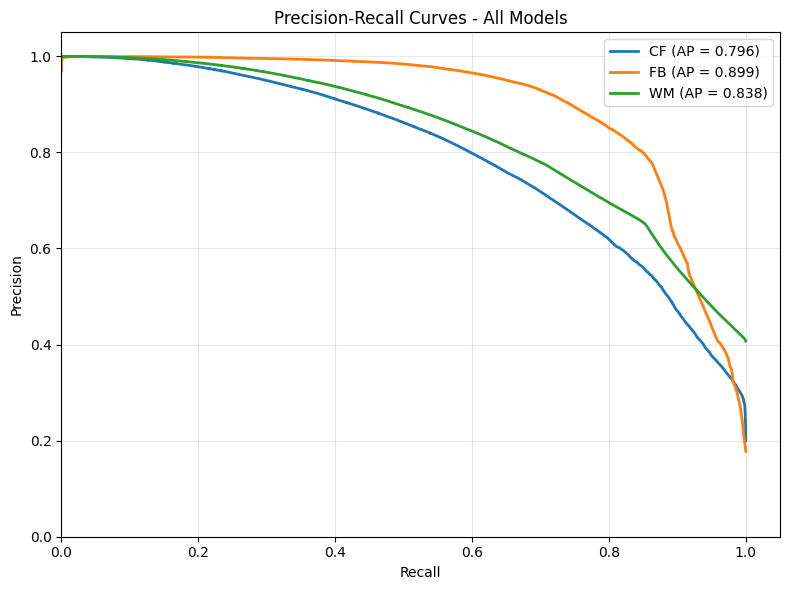

In [22]:
# Plot PRC curves for all models
plt.figure(figsize=(8, 6))
plt.plot(cf_stats['recall'], cf_stats['precision'], lw=2, 
         label=f"CF (AP = {cf_stats['prc_auc']:.3f})")
plt.plot(fb_stats['recall'], fb_stats['precision'], lw=2, 
         label=f"FB (AP = {fb_stats['prc_auc']:.3f})")
plt.plot(wm_stats['recall'], wm_stats['precision'], lw=2, 
         label=f"WM (AP = {wm_stats['prc_auc']:.3f})")
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/figs/all_models_prc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

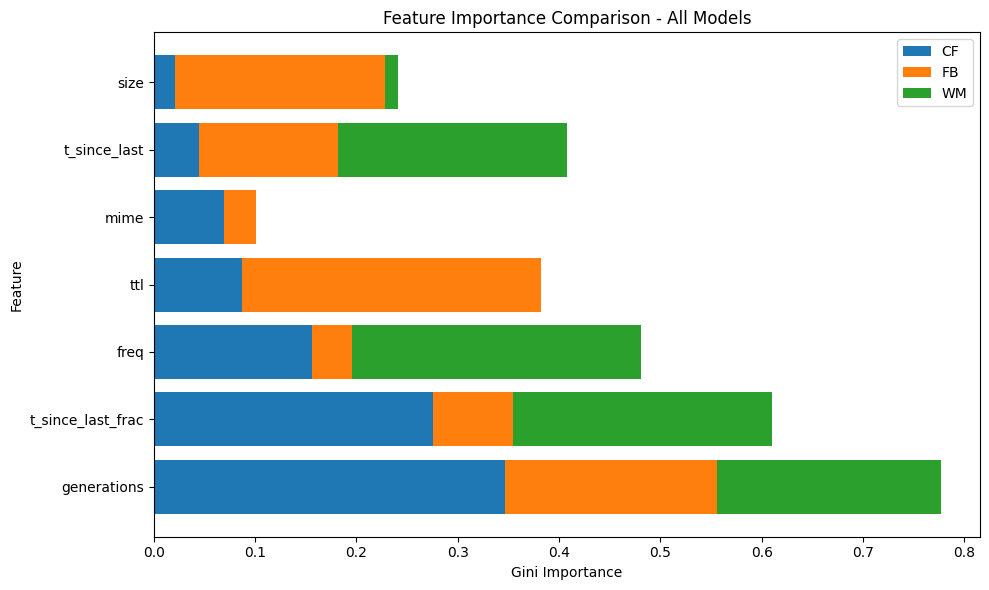

In [27]:
# Plot feature importances for all models as stacked bar chart
features = cf_stats['feature_importance']['feature'].tolist()
cf_importances = cf_stats['feature_importance']['importance'].tolist()
fb_importances = fb_stats['feature_importance'].set_index('feature').loc[features, 'importance'].tolist()
wm_importances = wm_stats['feature_importance'].set_index('feature').loc[features, 'importance'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(features, cf_importances, label='CF')
ax.barh(features, fb_importances, left=cf_importances, label='FB')
ax.barh(features, wm_importances, left=np.array(cf_importances) + np.array(fb_importances), label='WM')

ax.set_xlabel('Gini Importance')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance Comparison - All Models')
ax.legend()
plt.tight_layout()
plt.savefig('../paper/figs/all_models_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

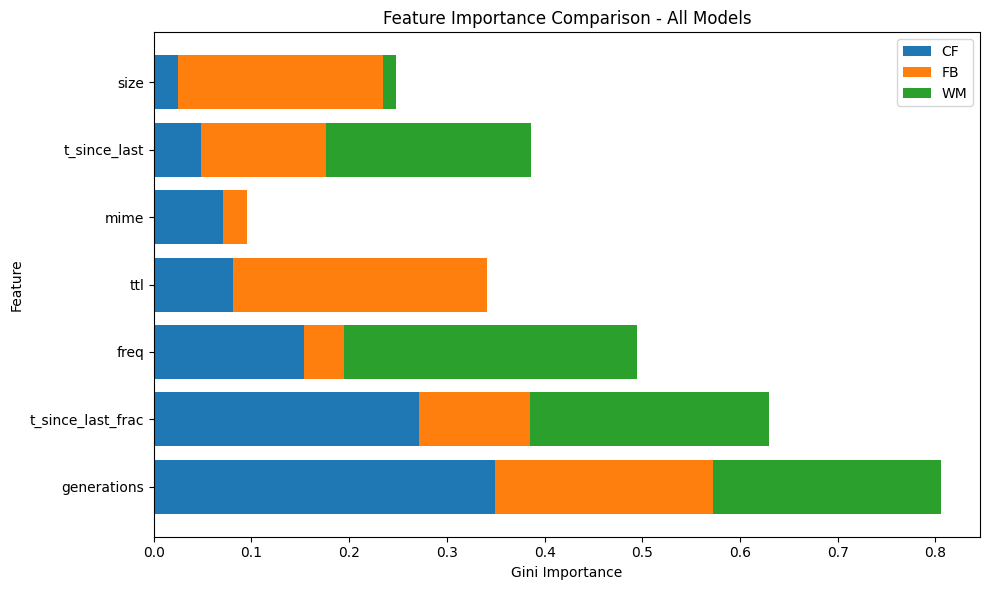

In [9]:
# Plot feature importances for all models as stacked bar chart
features = cf_stats['feature_importance']['feature'].tolist()
cf_importances = cf_stats['feature_importance']['importance'].tolist()
fb_importances = fb_stats['feature_importance'].set_index('feature').loc[features, 'importance'].tolist()
wm_importances = wm_stats['feature_importance'].set_index('feature').loc[features, 'importance'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(features, cf_importances, label='CF')
ax.barh(features, fb_importances, left=cf_importances, label='FB')
ax.barh(features, wm_importances, left=np.array(cf_importances) + np.array(fb_importances), label='WM')

ax.set_xlabel('Gini Importance')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance Comparison - All Models')
ax.legend()
plt.tight_layout()
plt.savefig('../paper/figs/all_models_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# try out random heuristic models

In [35]:
def get_heuristic_model(min_ttl=1, min_freq=1, max_t_since_last_frac=1.0):
    return lambda d: (d['ttl'] <= min_ttl) & (d['freq'] <= min_freq) & (d['t_since_last_frac'] <= max_t_since_last_frac)

ttls = [0, 1, 2, 3, 4, 5, 10, 15, 30, 60, 300, 900, 3600, 21600, 86400, 7*86400]
freqs = list(range(0, 7))
t_since_last_fracs = list(np.linspace(0.0, 1.0, num=20))

import itertools
heuristics = [get_heuristic_model(*h) for h in itertools.product(ttls, freqs, t_since_last_fracs)]
print(f'Generated {len(heuristics)} heuristics.')

Generated 2240 heuristics.


In [37]:
from sklearn.metrics import precision_score, recall_score

# test on cf

X_all, y_all = split_xy(df_cfall.sample(frac=0.1, random_state=42))
prevalence = y_all.sum() / len(y_all)

# Evaluate each heuristic
heuristic_results = []
for i, heuristic in enumerate(heuristics):
    print('.', end='', flush=True)
    if i % 100 == 0 and i > 0:
        print()
    y_pred = heuristic(X_all)
    
    # Only compute metrics if model makes at least one positive prediction
    if y_pred.sum() > 0:
        precision = precision_score(y_all, y_pred, zero_division=0)
        recall = recall_score(y_all, y_pred, zero_division=0)
        heuristic_results.append({
            'heuristic_id': i,
            'precision': precision,
            'recall': recall
        })

heuristic_df = pd.DataFrame(heuristic_results)
print('\ndone')

.....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
..........................................................................................

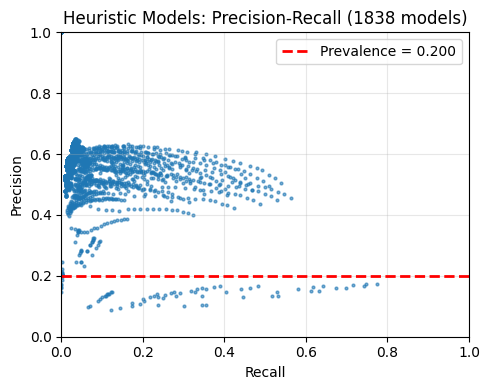

Total heuristics evaluated: 1838
Prevalence: 0.1996
Best precision: 1.0000
Best recall: 0.7743


In [44]:

# Plot precision-recall scatter with prevalence baseline
plt.figure(figsize=(5, 4))
plt.scatter(heuristic_df['recall'], heuristic_df['precision'], alpha=0.6, s=4)

# Prevalence baseline line: at any recall, precision should be >= prevalence
plt.plot([0, 1], [prevalence, prevalence], 'r--', lw=2, label=f'Prevalence = {prevalence:.3f}')

plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Heuristic Models: Precision-Recall ({len(heuristic_results)} models)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/figs/heuristic_precision_recall_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total heuristics evaluated: {len(heuristic_results)}")
print(f"Prevalence: {prevalence:.4f}")
print(f"Best precision: {heuristic_df['precision'].max():.4f}")
print(f"Best recall: {heuristic_df['recall'].max():.4f}")